# Old Boys' Club Bank — a worked example

This notebook walks through every causal-attribution quantity discussed in
the Old Boys' Club Bank (OBCB) example in the paper, computed analytically 
on the structural causal model. OBCB is the paper's running
example: a deliberately simple loan-approval model where two applicants are
rejected for *structurally different* reasons, and where most standard
attribution methods get at least one of them wrong. We go through the following:

- exact closed-form values for Probability of Necessity (PN), Probability of Sufficiency (PS),
Probability of Necessity and Sufficiency (PNS), Average Treatment Effect (ATE), 
Conditional Average Treatment Effect (CATE), Shapley values (SHAP) / Causal SHAP and
  PCI (Probabilistic Causal Impact, the paper's method) at both the population
  and the individual level, for our two applicants Alice and Bob;
- a side-by-side comparison table of all six methods, followed by a
  pass/fail table against the paper's *desiderata* (the formal conditions a good
  attribution score should meet here);
- a sense of *why* the failing methods fail — the main issue comes down to a single
  mediator, `check_failed`, that every intervention propagates through unless
  something pins it in place.

The narrative follows the paper. We build up the argument in
roughly increasing sophistication: PN/PS/PNS first (their successes and blind
spots), then ATE/CATE (which share PNS's blind spot), then PCI (which fixes it
via the *witness mechanism*), then SHAP / Causal SHAP for the
feature-attribution comparison, and finally a 3-feature extension that exposes
a separate SHAP failure mode. Throughout, the test case to watch is **Alice**:
the correct attribution says her gender, not her credit, caused her rejection,
and most methods disagree.

We assume light familiarity with probability and the idea of a causal intervention ($\mathrm{do}(\cdot)$), but *not* with the causal-attribution literature — each method is motivated in a sentence where it first appears. The notebook is meant to be read at three levels: the prose alone tells the whole story; the markdown tables give the numbers; the code cells are there only if you want to see exactly how a quantity is computed.

> *Aside on the paper's discussion also defines a deterministic version of
> OBCB used to introduce actual causality. This notebook implements only
> the stochastic version, since that is the one PN/PS/PNS/ATE/CATE/PCI all
> need.

## Outline

1. The model
2. Probability of Necessity (PN)
3. Probability of Sufficiency (PS)
4. Probability of Necessity and Sufficiency (PNS)
5. Treatment effects (ATE, CATE, ITE)
6. PCI — Probabilistic Causal Impact (the witness mechanism)
7. SHAP / Causal SHAP — 2-feature game, plus the six-method comparison table
8. 3-feature extension — a separate SHAP failure mode
9. Takeaways


---

## 1. The model

OBCB is a fictional bank with a discriminatory loan policy.
Male applicants are nearly always credit-checked (90%); female applicants
almost never are (20%). Unchecked applicants are denied automatically. If
the check happens, your credit determines whether you pass, with a small
slack at the edges: a man who fails the check is still approved 5% of the
time, and a woman who passes is denied 10% of the time.

We follow two applicants throughout:

- **Alice** — female, bad credit, rejected. Most likely she was never
  checked (since the bank rarely checks women), in which case her credit
  was never even evaluated.
- **Bob** — male, bad credit, rejected. Almost certainly because he was
  checked and his credit failed.

The interesting question — and the one PN/PS/PNS get wrong in different
ways — is whether Alice's rejection should be attributed to her gender or
her credit.

The causal structure is shown in the DAG below — the orange node `check_failed` is the key mediator (and the witness PCI will later pin), and the green node `loan` is the outcome. The structural equations that generate it follow.


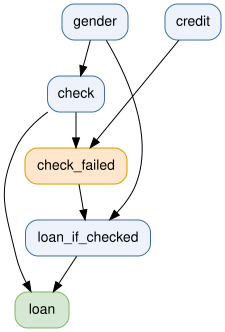

In [1]:
# Causal DAG for the OBCB model. The orange node `check_failed` is the mediator
# PCI uses as a witness; the green node `loan` is the outcome. Rendered with
# graphviz; falls back to a text edge-list if the graphviz binary is absent.
from IPython.display import display

try:
    from graphviz import Digraph

    g = Digraph("OBCB", graph_attr={"rankdir": "TB"})
    g.attr("node", shape="box", style="rounded,filled",
           fontname="Helvetica", color="#3b6ea5", fillcolor="#eef3fb")
    for n in ["gender", "credit", "check", "loan_if_checked"]:
        g.node(n)
    g.node("check_failed", fillcolor="#ffe6cc", color="#d79b00")  # mediator / witness
    g.node("loan", fillcolor="#d5e8d4", color="#82b366")          # outcome

    for a, b in [
        ("gender", "check"), ("gender", "loan_if_checked"),
        ("credit", "check_failed"), ("check", "check_failed"),
        ("check", "loan"), ("check_failed", "loan_if_checked"),
        ("loan_if_checked", "loan"),
    ]:
        g.edge(a, b)

    with g.subgraph() as roots:   # keep the two exogenous roots side by side
        roots.attr(rank="same")
        roots.node("gender")
        roots.node("credit")

    display(g)
except Exception as exc:  # pragma: no cover - graphviz binary missing
    print(f"(graphviz unavailable: {exc}; showing edge list instead)\n")
    for line in ["gender → check", "gender → loan_if_checked",
                 "credit → check_failed", "check → check_failed",
                 "check → loan", "check_failed → loan_if_checked",
                 "loan_if_checked → loan"]:
        print("  " + line)


Notice the following:

- Gender affects loan through two routes. Directly via `gender → check →
  loan` (gating whether a check happens at all), and indirectly via
  `gender → loan_if_checked` (modulating how strict the check is).
- `check_failed` is the key mediator. It carries credit's signal into the
  loan decision, and it is the witness PCI will use to distinguish Alice's
  unchecked branch from Bob's checked-and-failed branch.

**Structural equations.**

| Variable | Equation |
|---|---|
| `gender`, `credit` | Independent exogenous noise, $\mathrm{Bern}(0.5)$ each |
| `check` | $\mathrm{Bern}(0.9)$ if male, $\mathrm{Bern}(0.2)$ if female |
| `check_failed` | `check` $\times\,(1 -$ `credit`$)$ |
| `loan_if_checked` | $\mathrm{Bern}(p_{g,cf})$ — see matrix below |
| `loan` | `loan_if_checked` $\times$ `check` |

**Loan probability matrix** $p_{g,cf}$:

|  | passed (`cf=0`) | failed (`cf=1`) |
|---|---|---|
| female | 0.90 | 0.00 |
| male   | 1.00 | 0.05 |

For every quantity below we marginalise over the random `check` (which is
not directly observed) and condition on whatever observables the quantity
asks us to.



---

### The desiderata — what a correct attribution must say here

Before computing anything it helps to write down the *target*: the conditions
any good attribution score should satisfy on this example. We follow the paper
and grade every method below against the same seven **desiderata**. They are
stated for our two applicants and refer to a generic responsibility score
$R(V \rightsquigarrow \mathrm{loan} \mid \text{person})$ — a placeholder for
whatever number a given method assigns to variable $V$ for the loan outcome
(PN, PNS, SHAP, PCI, …). Because some methods produce signed values, the
conditions are stated on magnitudes $\lvert R(\cdot)\rvert$; below we abbreviate
$R(V \rightsquigarrow \mathrm{loan}\mid\cdot)$ as $R(V\mid\cdot)$.

| Name | In words | Condition |
|---|---|---|
| **D-A1** | gender mattered for Alice | $\lvert R(\text{gender}\mid\text{Alice})\rvert > 0$ |
| **D-A2** | credit mattered for Alice | $\lvert R(\text{credit}\mid\text{Alice})\rvert > 0$ |
| **D-A-rank** | for Alice, gender outranks credit | $\lvert R(\text{gender}\mid\text{Alice})\rvert > \lvert R(\text{credit}\mid\text{Alice})\rvert$ |
| **D-B1** | gender mattered for Bob (strictly) | $\lvert R(\text{gender}\mid\text{Bob})\rvert > 0$ |
| **D-B2** | credit mattered for Bob | $\lvert R(\text{credit}\mid\text{Bob})\rvert > 0$ |
| **D-B-rank** | for Bob, credit outranks gender | $\lvert R(\text{credit}\mid\text{Bob})\rvert > \lvert R(\text{gender}\mid\text{Bob})\rvert$ |
| **D-comp** | gender matters more for Alice than for Bob | $\lvert R(\text{gender}\mid\text{Alice})\rvert > \lvert R(\text{gender}\mid\text{Bob})\rvert$ |

The reasoning behind them is just the structural story of the model:

- **D-A1 / D-A2** — Alice has *two* live causal routes, so neither feature is
  inert: her gender filtered her out at the checking stage (women are rarely
  checked), while bad credit *would* have mattered had she been checked.
- **D-A-rank** is the substantive one. Alice was never credit-checked, so
  gender's role is immediate while credit's is purely hypothetical — gender
  should win.
- **D-B1 / D-B2 / D-B-rank** — Bob *was* checked and failed, so credit is the
  proximate cause and should outrank gender; but being male is what opened the
  check at all, so gender must still come out strictly nonzero.
- **D-comp** is the cross-individual asymmetry, and the hardest for naive
  methods: gender was *sufficient on its own* to reject Alice (no evaluation
  happened), whereas for Bob gender merely opened the door that credit then
  closed — so gender should carry more responsibility for Alice than for Bob.

These seven are exactly the rows of the pass/fail audit assembled in §7 (the
six-method comparison). Watch the **D-A-rank** row in particular: as we will
see, **PCI with witnesses is the only method that satisfies all seven**.

In [2]:
import os

# Smoke-test mode is triggered by ``CI=1``. The OBCB notebook is fully
# analytical (no Monte Carlo, no fitting), so the flag merely keeps the
# convention consistent with the heavier notebooks in this docs/source set.
smoke_test = "CI" in os.environ

import pandas as pd

# ── Model parameters ─────────────────────────────────────────────────────────
# P(check=1 | gender)
p_check = {0: 0.2, 1: 0.9}  # 0=female, 1=male

# P(loan_if_checked=1 | gender, check_failed)
# check_failed = check * (1-credit); equals 1 only when check=1 AND credit=bad.
loan_prob = {
    (0, 0): 0.9,  # female, check_failed=0  (checked+good OR unchecked, but see note)
    (0, 1): 0.0,  # female, check_failed=1  (checked+bad → always denied)
    (1, 0): 1.0,  # male,   check_failed=0
    (1, 1): 0.05,  # male,   check_failed=1  (checked+bad → 5% approved)
}


def p_loan(gender, credit):
    """P(loan=1 | gender, credit) for the STOCHASTIC model.

    Structural equation: loan = loan_if_checked * check
    So loan=1 requires check=1.  When check=0, loan=0 regardless of credit.

    Decomposition:
      P(loan=1) = P(check=1) * P(loan_if_checked=1 | check=1, credit)

    Given check=1: check_failed = 1 * (1-credit) = 1-credit, so we index
    loan_prob by (gender, 1-credit).  The check=0 branch contributes 0.
    """
    check_failed_given_checked = 1 - credit
    return p_check[gender] * loan_prob[(gender, check_failed_given_checked)]


# Sanity check: print all four marginal loan probabilities
print("P(loan=1 | gender, credit):")
for g, gl in [(0, "female"), (1, "male")]:
    for c, cl in [(0, "bad"), (1, "good")]:
        print(f"  {gl:6s}, {cl:4s}: {p_loan(g, c):.4f}")

P(loan=1 | gender, credit):
  female, bad : 0.0000
  female, good: 0.1800
  male  , bad : 0.0450
  male  , good: 0.9000


---

## 2. Probability of Necessity (PN)

PN focuses on the question: *Had the cause been absent, would the outcome still have occurred?*

$$\mathrm{PN}(C = c^\star,\, Y = 0) = P(\mathrm{loan}_{C = c'} = 1 \mid C = c^\star,\, Y = 0)$$

that is: take an applicant who actually had the cause ($C = c^\star$) and was rejected ($Y = 0$); PN is the probability that switching the cause to its alternative ($C = c'$) would have *approved* them ($\mathrm{loan} = 1$). A high PN means the cause was *necessary* — remove it and the rejection would most likely not have happened.

PN is the classical *necessity* measure from the actual-causality literature (Pearl; Halpern & Pearl): it asks whether the cause was *needed* for the outcome. It is the natural first question when we want to know whether something was “the reason” a decision went the way it did.

We ask this at two levels:

- **Population level.** Average over the credit distribution among rejected
  applicants of the given gender (or vice versa). This asks "how often is
  the cause necessary in the population?"
- **Individual level.** Fix the other factual variable too (so for Alice,
  condition on gender = female *and* credit = bad). This asks "how often is
  the cause necessary *for someone like Alice*?"

The main mechanical step is averaging over the random `check`, which is
unobserved. We do that with the structural equations directly — exactly the
averaging PCI will do later.

In [3]:
# ── Helper: posterior on credit within a (gender, loan=0) stratum ─────────────


def p_joint_loan0(gender, credit):
    """P(gender, credit, loan=0) — assuming P(gender)=P(credit)=0.5."""
    return 0.5 * 0.5 * (1 - p_loan(gender, credit))


def p_credit_given_gender_loan0(credit, gender):
    """P(credit | gender, loan=0) — posterior on credit for rejected applicants."""
    numerator = p_joint_loan0(gender, credit)
    denominator = sum(p_joint_loan0(gender, c) for c in [0, 1])
    return numerator / denominator


print(
    "P(credit | gender, loan=0) — posterior credit distribution among rejected applicants:"
)
for g, gl in [(0, "female"), (1, "male")]:
    for c, cl in [(0, "bad"), (1, "good")]:
        print(f"  {gl:6s}, {cl:4s}: {p_credit_given_gender_loan0(c, g):.4f}")

P(credit | gender, loan=0) — posterior credit distribution among rejected applicants:
  female, bad : 0.5495
  female, good: 0.4505
  male  , bad : 0.9052
  male  , good: 0.0948


In [4]:
# ── Population PN: gender ─────────────────────────────────────────────────────
# PN(gender=g, loan=F) = E_{credit ~ posterior(g, loan=0)}[ P(loan=1 | do(gender=g'), credit) ]


def pn_gender(observed_gender, counterfactual_gender):
    return sum(
        p_credit_given_gender_loan0(c, observed_gender)
        * p_loan(counterfactual_gender, c)
        for c in [0, 1]
    )


pn_male = pn_gender(observed_gender=1, counterfactual_gender=0)
pn_female = pn_gender(observed_gender=0, counterfactual_gender=1)

print(f"PN(gender=male,   loan=F) = {pn_male:.4f}")
print(f"PN(gender=female, loan=F) = {pn_female:.4f}")

# ── Population PN: credit ─────────────────────────────────────────────────────
# Symmetric construction: condition on (credit=observed, loan=0) and marginalise over gender.


def p_gender_given_credit_loan0(gender, credit):
    """P(gender | credit, loan=0)."""
    numerator = p_joint_loan0(gender, credit)
    denominator = sum(p_joint_loan0(g, credit) for g in [0, 1])
    return numerator / denominator


def pn_credit(observed_credit, counterfactual_credit):
    return sum(
        p_gender_given_credit_loan0(g, observed_credit)
        * p_loan(g, counterfactual_credit)
        for g in [0, 1]
    )


pn_credit_bad = pn_credit(observed_credit=0, counterfactual_credit=1)
print(f"PN(credit=bad,    loan=F) = {pn_credit_bad:.4f}")

PN(gender=male,   loan=F) = 0.0171
PN(gender=female, loan=F) = 0.4302
PN(credit=bad,    loan=F) = 0.5317


**What PN tells us at the population level.**

Gender PN is asymmetric across the two genders. A rejected woman has high
PN for her gender (0.43): had she been male, she would quite likely have
been approved, because she would have been checked and might have passed.
A rejected man has near-zero PN for his gender (0.02): had he been female,
she would still have been rejected — unchecked women never get loans here.

Credit PN is symmetric across genders (0.53 for both). At the population
level, credit being "good" tips a rejected applicant's odds the same way
regardless of gender, because the population value averages over a fairly
uniform credit-check stratum.

These are reasonable group-level statements but, as we are about to see,
they say nothing specific about Alice or Bob.

In [5]:
# ── Individual PN: Alice (female, bad credit) ─────────────────────────────────
#
# Context is fixed: (gender=female, credit=bad). No averaging needed.
#
# PN(gender=female | Alice) = P(loan=1 | do(gender=male), credit=bad)
pn_alice_gender = p_loan(gender=1, credit=0)  # male, bad credit

# PN(credit=bad | Alice) = P(loan=1 | do(credit=good), gender=female)
pn_alice_credit = p_loan(gender=0, credit=1)  # female, good credit

print(f"PN(gender=female | Alice) = {pn_alice_gender:.4f}")
print(f"PN(credit=bad    | Alice) = {pn_alice_credit:.4f}")

# ── Individual PN: Bob (male, bad credit) ─────────────────────────────────────
#
# PN(gender=male | Bob) = P(loan=1 | do(gender=female), credit=bad)
# loan_prob[female, check_failed=1] = 0.0, so this is exactly 0.
pn_bob_gender = p_loan(gender=0, credit=0)  # female, bad credit

# PN(credit=bad | Bob) = P(loan=1 | do(credit=good), gender=male)
pn_bob_credit = p_loan(gender=1, credit=1)  # male, good credit

print(f"\nPN(gender=male   | Bob)   = {pn_bob_gender:.4f}")
print(f"PN(credit=bad    | Bob)   = {pn_bob_credit:.4f}")

PN(gender=female | Alice) = 0.0450
PN(credit=bad    | Alice) = 0.1800

PN(gender=male   | Bob)   = 0.0000
PN(credit=bad    | Bob)   = 0.9000


**What PN tells us about Alice and Bob.**

At the individual level, PN drops noticeably for Alice's gender, from 0.43
to **0.045**. Conditioning on her bad credit means the counterfactual male
version of Alice would still most likely fail the credit check — any small
chance of approval now comes only from the 5% slack the bank gives to
credit-failed males.

Bob's gender PN is exactly **0**. A female version of Bob, with bad credit,
has zero chance of approval under this model: unchecked women always lose,
and women who do get checked then fail the bad-credit check (the
loan-probability matrix gives 0 for `female + check_failed`).

There is already something uncomfortable here. PN at the individual level
says gender is barely responsible for Alice's denial (0.045) — a number
that *should* be high if we believe the bank's discriminatory policy is
what caused her rejection. We will return to this.

---

## 3. Probability of Sufficiency (PS)

*Had the cause been present when it was absent, would the outcome have
occurred?*

$$\mathrm{PS}(C = c^\star,\, Y = 0) = P(\mathrm{loan}_{C = c^\star} = 0 \mid C = c',\, Y = 1)$$

that is: take an applicant who did *not* have the cause ($C = c'$) and was approved ($Y = 1$); PS is the probability that *introducing* the cause ($C = c^\star$) would have flipped them to rejected ($\mathrm{loan} = 0$). A high PS means the cause is *sufficient* — add it and the rejection appears.

PS is the *sufficiency* counterpart to PN, and it is worth computing because a cause we would call truly responsible should score on both counts — necessary *and* sufficient. §4 then fuses the two into a single number.

Start from someone who was *approved* and whose
cause was *absent*, then ask: had the cause been present, would they have
been rejected?

As before, we marginalise over the random `check` using the structural
equations.

In [6]:
# ── Helper: posterior on credit within a (gender, loan=1) stratum ─────────────


def p_credit_given_gender_loan1(credit, gender):
    """P(credit | gender, loan=1) — posterior credit among approved applicants."""
    numerator = 0.5 * p_loan(gender, credit)
    denominator = sum(0.5 * p_loan(gender, c) for c in [0, 1])
    return numerator / denominator


# ── Population PS: gender ─────────────────────────────────────────────────────
# PS(gender=g, loan=F) = E_{credit ~ posterior(g', loan=1)}[ P(loan=0 | do(gender=g), credit) ]


def ps_gender(factual_gender, counterfactual_gender):
    return sum(
        p_credit_given_gender_loan1(c, counterfactual_gender)
        * (1 - p_loan(factual_gender, c))
        for c in [0, 1]
    )


ps_male = ps_gender(factual_gender=1, counterfactual_gender=0)
ps_female = ps_gender(factual_gender=0, counterfactual_gender=1)

print(f"PS(gender=male,   loan=F) = {ps_male:.4f}")
print(f"PS(gender=female, loan=F) = {ps_female:.4f}")

# ── Population PS: credit ─────────────────────────────────────────────────────


def p_gender_given_credit_loan1(gender, credit):
    """P(gender | credit, loan=1)."""
    numerator = 0.5 * p_loan(gender, credit)
    denominator = sum(0.5 * p_loan(g, credit) for g in [0, 1])
    return numerator / denominator


def ps_credit(factual_credit, counterfactual_credit):
    return sum(
        p_gender_given_credit_loan1(g, counterfactual_credit)
        * (1 - p_loan(g, factual_credit))
        for g in [0, 1]
    )


ps_credit_bad = ps_credit(factual_credit=0, counterfactual_credit=1)
print(f"PS(credit=bad,    loan=F) = {ps_credit_bad:.4f}")

PS(gender=male,   loan=F) = 0.1000
PS(gender=female, loan=F) = 0.8286
PS(credit=bad,    loan=F) = 0.9625


**What PS tells us at the population level.**

Gender PS is asymmetric. A randomly chosen approved man, had he been a
woman, would almost certainly have been rejected — sufficiency 0.83 for
gender = female. The reverse is much smaller (0.10): an approved woman
made male would mostly still be approved, because male approvals are not
that exceptional.

Credit PS is near-certain (0.96). Nearly every approved applicant has good
credit, and intervening to give them bad credit nearly always rejects them.

PS gives the "if you put the cause in, would you flip the outcome?" view,
complementary to PN's "if you take the cause out, would you flip the
outcome?" view. Neither view on its own is enough for a single rank-able
score; for that we need to combine them into PNS.

In [7]:
# ── Individual PS: Alice (female, bad credit) ─────────────────────────────────
#
# PS(gender=female | Alice) = P(loan=0 | do(gender=female), credit=bad)
#   Conditioning event: (gender=male, credit=bad, loan=1).
#   P(loan=1 | male, bad) = 0.045 > 0, so this is well-defined.
#   After fixing context (female, bad), P(loan=1) = 0.0 → PS = 1.
ps_alice_gender = 1 - p_loan(gender=0, credit=0)  # = 1 - 0 = 1.0

# PS(credit=bad | Alice) = P(loan=0 | do(credit=bad), gender=female)
#   Conditioning event: (credit=good, gender=female, loan=1).
#   P(loan=1 | female, good) = 0.18 > 0, so this is well-defined.
#   After fixing context (female, bad), P(loan=1) = 0.0 → PS = 1.
ps_alice_credit = 1 - p_loan(gender=0, credit=0)  # = 1 - 0 = 1.0

print(f"PS(gender=female | Alice) = {ps_alice_gender:.4f}")
print(f"PS(credit=bad    | Alice) = {ps_alice_credit:.4f}")

# ── Individual PS: Bob (male, bad credit) ─────────────────────────────────────
#
# PS(gender=male | Bob):
#   Conditioning event requires (gender=female, credit=bad, loan=1).
#   P(loan=1 | female, bad) = 0 → conditioning event is impossible → UNDEFINED.
ps_bob_gender_conditioning_prob = p_loan(gender=0, credit=0)
print(
    f"\nPS(gender=male | Bob): conditioning event P = {ps_bob_gender_conditioning_prob} → UNDEFINED"
)

# PS(credit=bad | Bob) = P(loan=0 | do(credit=bad), gender=male)
#   Conditioning event: (credit=good, gender=male, loan=1).
#   P(loan=1 | male, good) = 0.9 > 0, so this is well-defined.
#   P(loan=1 | male, bad) = 0.9 × 0.05 = 0.045, so P(loan=0 | male, bad) = 0.955.
ps_bob_credit = 1 - p_loan(gender=1, credit=0)  # = 1 - 0.045 = 0.955
print(f"PS(credit=bad    | Bob)   = {ps_bob_credit:.4f}")

PS(gender=female | Alice) = 1.0000
PS(credit=bad    | Alice) = 1.0000

PS(gender=male | Bob): conditioning event P = 0.0 → UNDEFINED
PS(credit=bad    | Bob)   = 0.9550


**What PS tells us about Alice and Bob.** Both of Alice's individual PS values are
exactly **1**: starting from an applicant who *was* approved, forcing in
Alice's factual context (female, bad credit) drives the approval probability
to 0, so flipping the outcome is certain. This is the mirror image of her
near-zero PN — sufficiency and necessity can disagree sharply at the
individual level.

Bob's gender PS is **undefined**: it conditions on a female-with-bad-credit
applicant being approved, an event with probability 0 under this model
(unchecked women never get loans, checked women with bad credit fail). His
credit PS is well-defined and near-certain (0.955). The undefined cell is a
first hint that PN/PS in isolation are brittle on this example; PNS, which we
turn to next, combines both directions into a single score.


---

## 4. Probability of Necessity and Sufficiency (PNS)

The question that PNS attempts to answer is about the probability of *the outcome occuring under the factual cause but not under the
alternative?*

$$\mathrm{PNS}(C = c^\star,\, Y = 0) = P(Y_{c^\star} = 0,\; Y_{c'} = 1)$$

that is: the probability that *one and the same* applicant — the same individual under the same exogenous-noise draw — would be rejected under the factual cause ($Y_{c^\star} = 0$) and approved under the alternative ($Y_{c'} = 1$). Necessity and sufficiency are required to hold *together*, in the same counterfactual world.

PNS is a single quantity that's high only when the cause is both necessary
(removing it would flip the outcome) and sufficient (adding it would
produce the outcome). It is the closest of the PN/PS family to a
"responsibility" score.

PN asked whether removing the cause would have flipped the outcome; PS asked whether adding it would have produced the outcome. PNS asks for **both to hold in the same counterfactual world** — the same individual, the same noise draw — rather than averaging the two separately. That is why it is a *joint* probability $P(Y_{c^\star}=0,\,Y_{c'}=1)$ and not the product $\mathrm{PN}\cdot\mathrm{PS}$: a product would let necessity hold for one hypothetical person and sufficiency for another, whereas responsibility requires them to coincide.

Under the assumption that the exogenous noise variables are independent
(which holds in our model — gender, credit and check noise are independent
draws), PNS decomposes into a sum over the noise regions:

$$\mathrm{PNS} = \sum_{\text{ctx}} P(\text{ctx}) \cdot P(Y = 0 \mid C = c^\star,\, \text{ctx}) \cdot P(Y = 1 \mid C = c',\, \text{ctx}).$$

that is: split on the exogenous context (here the three `check`-noise regions); within each context multiply the chance of rejection under the factual cause by the chance of approval under the alternative, then average over contexts weighted by $P(\text{ctx})$. Noise independence is exactly what lets the joint probability factor into this per-context product.

We just need to enumerate the contexts (the three `check`-noise regions)
and sum.

In [8]:
# ── Population PNS: gender ────────────────────────────────────────────────────
# PNS(gender=g, loan=F) = E_{credit}[ P(loan=0 | g, credit) × P(loan=1 | g', credit) ]


def pns_gender(factual_gender, counterfactual_gender):
    return sum(
        0.5 * (1 - p_loan(factual_gender, c)) * p_loan(counterfactual_gender, c)
        for c in [0, 1]
    )


pns_male = pns_gender(factual_gender=1, counterfactual_gender=0)
pns_female = pns_gender(factual_gender=0, counterfactual_gender=1)

print(f"PNS(gender=male,   loan=F) = {pns_male:.4f}")
print(f"PNS(gender=female, loan=F) = {pns_female:.4f}")

# ── Population PNS: credit ────────────────────────────────────────────────────
# PNS(credit=c, loan=F) = E_{gender}[ P(loan=0 | gender, c) × P(loan=1 | gender, c') ]


def pns_credit(factual_credit, counterfactual_credit):
    return sum(
        0.5 * (1 - p_loan(g, factual_credit)) * p_loan(g, counterfactual_credit)
        for g in [0, 1]
    )


pns_credit_bad = pns_credit(factual_credit=0, counterfactual_credit=1)
print(f"PNS(credit=bad,    loan=F) = {pns_credit_bad:.4f}")

PNS(gender=male,   loan=F) = 0.0090
PNS(gender=female, loan=F) = 0.3915
PNS(credit=bad,    loan=F) = 0.5197


**What PNS tells us — and where it breaks.**

PNS for Alice ranks credit (0.18) above gender (0.045). That is the wrong
answer if we believe the bank's policy carried Alice's denial: she was
never even evaluated for credit. PNS has no mechanism to register this —
intervening on credit propagates through `check_failed` (the mediator) and
overrides the contextual fact that her check never happened.

PNS for Bob ranks credit (0.86) above gender (0). That is correct: his
denial really was caused by the failed credit check.

The asymmetry between Alice and Bob is the heart of why §3 of the paper
introduces the **D-comp** desideratum — gender should be *strictly more*
responsible for Alice's denial than for Bob's. PNS happens to satisfy
D-comp here only because Bob's gender PNS is exactly zero, not because PNS
understands the structural difference between their cases. As we will see
next, ATE and CATE share this limitation; PCI then fixes it.

In [9]:
# ── Individual PNS: Alice (female, bad credit) ────────────────────────────────
#
# PNS_c(gender=female | credit=bad) = P(loan=0|female,bad) × P(loan=1|male,bad)
pns_alice_gender = (1 - p_loan(0, 0)) * p_loan(1, 0)

# PNS_c(credit=bad | gender=female) = P(loan=0|female,bad) × P(loan=1|female,good)
pns_alice_credit = (1 - p_loan(0, 0)) * p_loan(0, 1)

print(f"PNS_c(gender=female | credit=bad)  [Alice] = {pns_alice_gender:.4f}")
print(f"PNS_c(credit=bad    | gender=female) [Alice] = {pns_alice_credit:.4f}")

# ── Individual PNS: Bob (male, bad credit) ───────────────────────────────────
#
# PNS_c(gender=male | credit=bad) = P(loan=0|male,bad) × P(loan=1|female,bad)
#   P(loan=1 | female, bad) = 0 exactly, so PNS = 0.
pns_bob_gender = (1 - p_loan(1, 0)) * p_loan(0, 0)

# PNS_c(credit=bad | gender=male) = P(loan=0|male,bad) × P(loan=1|male,good)
#   = 0.955 × 0.9 = 0.8595 → rounds to 0.86, not 0.85 as in the paper.
pns_bob_credit = (1 - p_loan(1, 0)) * p_loan(1, 1)

print(f"\nPNS_c(gender=male   | credit=bad)  [Bob]   = {pns_bob_gender:.4f} ")
print(f"PNS_c(credit=bad    | gender=male) [Bob]   = {pns_bob_credit:.4f}")

PNS_c(gender=female | credit=bad)  [Alice] = 0.0450
PNS_c(credit=bad    | gender=female) [Alice] = 0.1800

PNS_c(gender=male   | credit=bad)  [Bob]   = 0.0000 
PNS_c(credit=bad    | gender=male) [Bob]   = 0.8595


---

## 5. Treatment effects (ATE, CATE, ITE)

Now let's use the same example and visit the classical metrics considered in the causal-inference literature. Do the standard causal-inference quantities — the **Average Treatment Effect (ATE)**, the **Conditional Average Treatment Effect (CATE)**, and the **Individual Treatment Effect (ITE)** — do any better than PNS on this example?

These are the tools a practitioner trained in causal inference reaches for first, so it is worth seeing exactly where they land here. The **ATE** is the average change in approval if we flipped the treatment for *everyone*; the **CATE** is that same average restricted to a subgroup picked out by covariates $X$ (e.g. applicants with bad credit); and the **ITE** (introduced below) is the effect for a *single named individual*, with their own circumstances held fixed.

### ATE and CATE

$$\mathrm{ATE}(T) = \mathbb{E}[Y \mid \mathrm{do}(T=1)] - \mathbb{E}[Y \mid \mathrm{do}(T=0)]$$

that is: the average change in approval probability if we forced the treatment *on* for everyone versus *off* for everyone — a population-level contrast with nothing held fixed.

$$\mathrm{CATE}(T \mid X = x) = \mathbb{E}[Y \mid \mathrm{do}(T=1), X=x] - \mathbb{E}[Y \mid \mathrm{do}(T=0), X=x]$$

that is: the same on-minus-off contrast, but restricted to the subgroup with covariates $X = x$ (e.g. applicants with bad credit). It conditions on $X$, yet still averages over everything else — including the hidden `check` noise.

We compute (i) population ATE for gender and for credit, and (ii) CATE for
Alice and Bob conditional on the *other* covariate.

In [10]:
# ── ATE and CATE on the stochastic OBCB model ────────────────────────────────
#
# Closed-form computation: marginalise over check (exogenous noise) and over
# any covariate not fixed by do() or conditioning, using the structural
# equations of the model cell above.

P_LOAN_GIVEN_CHECKED = {
    # (gender, check_failed): P(loan_if_checked = 1)
    (0, 0): 0.9,  # female, passed check
    (0, 1): 0.0,  # female, failed check
    (1, 0): 1.0,  # male,   passed check
    (1, 1): 0.05,  # male,   failed check
}


def E_loan(do_gender=None, do_credit=None, cond_gender=None, cond_credit=None):
    """E[loan | do(...), cond(...)] under the stochastic OBCB SCM.

    ``do_*``   sets the variable by intervention.
    ``cond_*`` conditions on an observed value.

    Since gender and credit are independent exogenous Bern(0.5) variables,
    conditioning and intervening on them coincide here. (This is not true for
    downstream variables like ``check_failed``.)
    """

    def grid(do_v, cond_v):
        if do_v is not None:
            return [(do_v, 1.0)]
        if cond_v is not None:
            return [(cond_v, 1.0)]
        return [(0, 0.5), (1, 0.5)]

    total = 0.0
    for g, pg in grid(do_gender, cond_gender):
        p_check_1 = 0.9 if g == 1 else 0.2
        for c, pc in grid(do_credit, cond_credit):
            for check, pchk in [(1, p_check_1), (0, 1 - p_check_1)]:
                if check == 0:
                    p_loan = 0.0
                else:
                    cf = 1 - c
                    p_loan = P_LOAN_GIVEN_CHECKED[(g, cf)]
                total += pg * pc * pchk * p_loan
    return total


# ── Population ATE ───────────────────────────────────────────────────────────
ate_gender = E_loan(do_gender=1) - E_loan(do_gender=0)
ate_credit = E_loan(do_credit=1) - E_loan(do_credit=0)

# ── CATE conditional on the *other* covariate ────────────────────────────────
# Alice: gender=female (0), credit=bad (0).  Bob: gender=male (1), credit=bad (0).
cate_gender_alice = E_loan(do_gender=1, cond_credit=0) - E_loan(
    do_gender=0, cond_credit=0
)
cate_credit_alice = E_loan(do_credit=1, cond_gender=0) - E_loan(
    do_credit=0, cond_gender=0
)
cate_gender_bob = E_loan(do_gender=1, cond_credit=0) - E_loan(
    do_gender=0, cond_credit=0
)
cate_credit_bob = E_loan(do_credit=1, cond_gender=1) - E_loan(
    do_credit=0, cond_gender=1
)

print(f"ATE(gender → loan)            = {ate_gender:.3f}")
print(f"ATE(credit → loan)            = {ate_credit:.3f}")
print()
print(
    f"CATE(gender | credit=bad)     = {cate_gender_alice:.3f}  "
    f"(Alice and Bob both, since both have credit=bad)"
)
print(f"CATE(credit | gender=female)  = {cate_credit_alice:.3f}  (Alice's value)")
print(f"CATE(credit | gender=male)    = {cate_credit_bob:.3f}    (Bob's value)")

# Sanity check: Alice's CATE values must coincide with her individual PNS.
assert abs(cate_credit_alice - pns_alice_credit) < 1e-9, (
    cate_credit_alice,
    pns_alice_credit,
)
assert abs(cate_gender_alice - pns_alice_gender) < 1e-9, (
    cate_gender_alice,
    pns_alice_gender,
)

ATE(gender → loan)            = 0.383
ATE(credit → loan)            = 0.518

CATE(gender | credit=bad)     = 0.045  (Alice and Bob both, since both have credit=bad)
CATE(credit | gender=female)  = 0.180  (Alice's value)
CATE(credit | gender=male)    = 0.855    (Bob's value)


Population ATE ranks credit (0.52) above gender (0.38)
— the same direction as population PN. Reasonable at the group level.
The problem is that conditional on Alice's gender, CATE for credit is **0.18**
and CATE for gender is **0.045**. These numbers are *exactly* Alice's
individual PNS values from §4. With binary outcomes and
PS = 1 in the relevant branches, CATE for a single treatment collapses to
PNS$_c$. CATE inherits the blind spot: the intervention on credit
propagates through `check_failed` and overrides the contextual fact that
Alice was never checked.

Another problem is that CATE conditions on
observable covariates but cannot condition on the factual value of the
treatment itself. So `CATE(gender | credit=bad) = 0.045` is the same
number for Alice and Bob, even though we would like gender to be
strictly more responsible for Alice's denial than Bob's. Alice was denied
because the bank refuses to check women; Bob was denied because his credit
check failed. CATE conflates them because it integrates over the very
check-noise distribution that distinguishes them. PCI's witness mechanism
(§6 below) breaks the symmetry by pinning `check_failed` at its factual
value — dominantly 0 for Alice (her unchecked branch, where credit is
causally disconnected from the loan) and dominantly 1 for Bob (his
checked-and-failed branch, where credit is the direct cause).

### Individual Treatment Effect (ITE)

ATE and CATE both still average over the hidden `check` noise. The genuine *unit-level* quantity is the **ITE**: we first *abduct* (infer) the individual's own exogenous noise from their **full** factual record — their covariates **and** the fact that they were denied — then ask the counterfactual “what if we flipped this one feature?”, holding that abducted noise fixed: the factual and counterfactual worlds share the same noise draw $u$.

It is the most refined of the three treatment effects and the closest classical quantity to PCI, so it is the sharpest test of whether *standard* counterfactuals already solve the problem — or whether the witness mechanism is really needed.

In [11]:
# ── Individual Treatment Effect (ITE): the unit-level counterfactual ─────────
#
# ATE marginalises all noise; CATE conditions on the *other* observed covariate
# but still re-marginalises the exogenous noise. The genuine unit-level quantity
# is the ITE: abduct the individual's exogenous noise from their FULL factual
# record — covariates AND the observed outcome (loan=0, denied) — then take the
# counterfactual contrast holding that abducted noise fixed. This is the
# abduction–action–prediction reading already used for PN in §2: factual and
# counterfactual worlds share the same noise draw u.
#
# Two exogenous noises matter:
#   U_check ~ Unif[0,1]  →  check = 1{U_check ≤ p_check[gender]}
#   U_loan  ~ Unif[0,1]  →  loan_if_checked = 1{U_loan ≤ loan_prob[(gender,cf)]}
# We discretise U_check into the three regions induced by the two thresholds
# (0.2 for female, 0.9 for male) and handle U_loan analytically.

ite_regions = [
    (0.2, "U_check ≤ 0.2"),  # both genders checked
    (0.7, "0.2 < U_check ≤ 0.9"),  # only male checked
    (0.1, "U_check > 0.9"),  # neither checked
]


def _checked(gender, region_idx):
    """Was the applicant check-evaluated in this U_check region?"""
    # female (0): checked only in region 0; male (1): checked in regions 0 and 1
    return region_idx == 0 if gender == 0 else region_idx in (0, 1)


def ite(factual_gender, factual_credit, target):
    """E[loan=1 | do(flip target), abducted noise] for a *denied* individual.

    The factual outcome is loan=0, so this counterfactual probability is exactly
    the unit-level treatment effect on approval: how much flipping ``target``
    (gender or credit), with the individual's own noise held fixed, would have
    raised the chance of approval.
    """
    # ── Abduction: P(region | gender, credit, denied) ∝ prior · P(denied|region) ──
    weights = []
    for idx, (prior, _) in enumerate(ite_regions):
        if _checked(factual_gender, idx):
            p_denied = 1 - loan_prob[(factual_gender, 1 - factual_credit)]
        else:
            p_denied = 1.0  # unchecked ⇒ denied with certainty
        weights.append(prior * p_denied)
    Z = sum(weights)
    posterior = [w / Z for w in weights]

    # ── Counterfactual: flip target, hold U_check (region) and U_loan fixed ──────
    cf_gender = 1 - factual_gender if target == "gender" else factual_gender
    cf_credit = 1 - factual_credit if target == "credit" else factual_credit

    effect = 0.0
    for idx, (prior, _) in enumerate(ite_regions):
        if not _checked(cf_gender, idx):
            continue  # unchecked under the flip ⇒ loan = 0
        q = loan_prob[(cf_gender, 1 - cf_credit)]  # cf approval prob given checked
        if _checked(factual_gender, idx):
            # U_loan abducted from the factual checked-and-denied branch: it lies
            # above the factual approval threshold, so it flips to approval only on
            # the extra probability mass the counterfactual opens up.
            p_app = loan_prob[(factual_gender, 1 - factual_credit)]
            p_flip = 0.0 if (q <= p_app or p_app >= 1) else (q - p_app) / (1 - p_app)
        else:
            # factually unchecked ⇒ U_loan was never used ⇒ a fresh Unif draw
            p_flip = q
        effect += posterior[idx] * p_flip
    return effect


# ── ITE for Alice (female, bad) and Bob (male, bad), both denied ─────────────
ite_gender_alice = ite(0, 0, "gender")
ite_credit_alice = ite(0, 0, "credit")
ite_gender_bob = ite(1, 0, "gender")
ite_credit_bob = ite(1, 0, "credit")

print("Individual Treatment Effect (unit-level counterfactual on approval):")
print(
    f"  ITE(gender | Alice) = {ite_gender_alice:.4f}    ITE(credit | Alice) = {ite_credit_alice:.4f}"
)
print(
    f"  ITE(gender | Bob)   = {ite_gender_bob:.4f}    ITE(credit | Bob)   = {ite_credit_bob:.4f}"
)
print()

# ── The ATE → CATE → ITE ladder, side by side ────────────────────────────────
ladder = pd.DataFrame(
    [
        ("Alice", "gender", ate_gender, cate_gender_alice, ite_gender_alice),
        ("Alice", "credit", ate_credit, cate_credit_alice, ite_credit_alice),
        ("Bob", "gender", ate_gender, cate_gender_bob, ite_gender_bob),
        ("Bob", "credit", ate_credit, cate_credit_bob, ite_credit_bob),
    ],
    columns=["Person", "Feature", "ATE", "CATE", "ITE"],
)
print(ladder.round(4).to_string(index=False))
print()

# ── What the numbers show ────────────────────────────────────────────────────
print("D-comp on gender — does the method separate Alice from Bob?")
print(
    f"  CATE: {cate_gender_alice:.3f} vs {cate_gender_bob:.3f}  ->  "
    f"{'SEPARATES' if abs(cate_gender_alice - cate_gender_bob) > 1e-6 else 'cannot separate'}"
)
print(
    f"  ITE:  {ite_gender_alice:.3f} vs {ite_gender_bob:.3f}  ->  "
    f"{'SEPARATES (Alice > Bob)' if ite_gender_alice > ite_gender_bob else 'cannot separate'}"
)
print()
print("D-A-rank for Alice — does the method rank gender above credit?")
print(
    f"  ITE:  gender {ite_gender_alice:.3f} {'>' if ite_gender_alice > ite_credit_alice else '<'} "
    f"credit {ite_credit_alice:.3f}  ->  "
    f"{'OK' if ite_gender_alice > ite_credit_alice else 'FAILS (same blind spot as PNS/CATE)'}"
)

# Sanity checks against the values derived by hand / Monte Carlo.
assert abs(ite_gender_alice - 0.045) < 1e-9, ite_gender_alice
assert abs(ite_credit_alice - 0.180) < 1e-9, ite_credit_alice
assert abs(ite_gender_bob - 0.000) < 1e-9, ite_gender_bob
assert abs(ite_credit_bob - 0.855 / 0.955) < 1e-9, ite_credit_bob

# ITE for a denied individual is a genuine counterfactual (abducts the OUTCOME),
# so it parts ways with the *interventional* individual-PN of the earlier cell:
# Bob's credit ITE is 0.895, not the population conditional P(loan=1|male,good)=0.90,
# because conditioning on his denial shifts mass toward the unchecked branch.
assert abs(ite_credit_bob - pn_bob_credit) > 1e-3, (ite_credit_bob, pn_bob_credit)
print(
    f"\nAbduction-on-outcome correction: ITE(credit|Bob)={ite_credit_bob:.4f} "
    f"vs interventional PN={pn_bob_credit:.4f}"
)

Individual Treatment Effect (unit-level counterfactual on approval):
  ITE(gender | Alice) = 0.0450    ITE(credit | Alice) = 0.1800
  ITE(gender | Bob)   = 0.0000    ITE(credit | Bob)   = 0.8953

Person Feature    ATE  CATE    ITE
 Alice  gender 0.3825 0.045 0.0450
 Alice  credit 0.5175 0.180 0.1800
   Bob  gender 0.3825 0.045 0.0000
   Bob  credit 0.5175 0.855 0.8953

D-comp on gender — does the method separate Alice from Bob?
  CATE: 0.045 vs 0.045  ->  cannot separate
  ITE:  0.045 vs 0.000  ->  SEPARATES (Alice > Bob)

D-A-rank for Alice — does the method rank gender above credit?
  ITE:  gender 0.045 < credit 0.180  ->  FAILS (same blind spot as PNS/CATE)

Abduction-on-outcome correction: ITE(credit|Bob)=0.8953 vs interventional PN=0.9000


**ATE → CATE → ITE** (effect on approval probability; each step conditions on more of the individual's situation):

| Person | Feature | ATE | CATE | ITE |
|---|---|---|---|---|
| Alice | gender | 0.383 | 0.045 | 0.045 |
| Alice | credit | 0.518 | 0.180 | 0.180 |
| Bob | gender | 0.383 | 0.045 | 0.000 |
| Bob | credit | 0.518 | 0.855 | 0.895 |

**The one-line summary.** Refining ATE → CATE → ITE makes the estimate progressively more individual, and ITE finally recovers the cross-applicant asymmetry **D-comp** that ATE and CATE both miss. But *none* of the three corrects Alice's wrong gender-vs-credit ranking (**D-A-rank**) — that needs PCI's witness mechanism (§6). The rest of this section walks through why.

The ITE is
the natural endpoint of the refinement ladder: ATE marginalises everything,
CATE conditions on the other covariate, and ITE abducts the individual's
exogenous noise from their *full* record — including the observed denial — then
asks the counterfactual question on that pinned noise.

*ITE fixes what CATE could not (D-comp).* `CATE(gender | credit=bad) = 0.045`
is identical for Alice and Bob, so CATE cannot say gender mattered more to one
than the other. ITE *can*: `ITE(gender | Alice) = 0.045` but
`ITE(gender | Bob) = 0`. Abduction places Bob in the checked-and-failed branch,
where being male is not what blocked him — flipping him to female (still bad
credit, still denied) changes nothing. So ITE recovers the cross-individual
asymmetry **D-comp** demands.

*ITE does not fix D-A-rank.* For Alice, `ITE(credit) = 0.18 > ITE(gender) = 0.045`,
the same wrong ranking as PNS and CATE. Abducting `U_check` still leaves a 20%
branch in which Alice was checked, and in that branch good credit would have
flipped the outcome — so credit keeps outranking gender. ITE abducts the
*noise* but not the *mechanism*. Recovering the correct **D-A-rank** ordering
needs PCI's witness mechanism, which pins `check_failed` at its factual value
(dominantly 0 for Alice, her unchecked branch where credit is causally
disconnected) rather than merely integrating over its noise.

Because ITE conditions on the outcome, `ITE(credit | Bob) = 0.895`, not the interventional
`P(loan=1 | do(credit=good), male) = 0.90` reported as Bob's individual PN
earlier: conditioning on his denial shifts posterior mass slightly toward the
unchecked branch. This is the abduction-on-outcome correction that separates a
true unit-level counterfactual from a do-query.

In short: **ITE is the right kind of object** — individual, counterfactual,
noise-abducted — and it strictly improves on CATE, but it inherits PNS's
blind spot on the mediated path. PCI is ITE plus the witness machinery needed
to see that path.

---

## 6. PCI — Probabilistic Causal Impact

PCI fixes PNS's blind spot via the *witness mechanism*: we hold a set of
intermediate variables fixed at their factual values during the
counterfactual evaluation, integrating against a distribution $\Gamma$
over which witness sets to use. For OBCB the natural witness is
`check_failed` — pinning it at its factual value lets us distinguish
"Alice's check never happened" from "Alice's credit was bad".

**Setup choices.**

- *Suspects* (the candidate causes): $\{g\}$, $\{c\}$, or $\{g, c\}$,
  with $\Gamma_s$ uniform over these three.
- *Witnesses*: $\emptyset$ or $\{\text{check\_failed}\}$, with $\Gamma_w$
  uniform over the two.
- *Alternative values*: point mass on the opposite binary value.
- *Outcome contrast*: PNS-style binary, $y^\star = \text{loan} = 0$.

Since the suspect and witness pools are disjoint, the joint $\Gamma$ is
just the product of $\Gamma_s$ and $\Gamma_w$ (no rejection sampling is
needed, normaliser $Z = 1$).

**The three regions of `check` noise.** It's convenient to label the
distinct outcomes of the `check` exogenous noise $U_{\text{check}}$ (think
of drawing $U \in [0,1]$ uniformly, with `check(female) = 1` iff
$U \leq 0.2$ and `check(male) = 1` iff $U \leq 0.9$):

| Region | Probability | `check(female)` | `check(male)` |
|---|---|---|---|
| $u_1$: $U \leq 0.2$ | 0.2 | 1 | 1 |
| $u_2$: $0.2 < U \leq 0.9$ | 0.7 | 0 | 1 |
| $u_3$: $U > 0.9$ | 0.1 | 0 | 0 |

Region $u_2$ is the critical one for Alice. She is unchecked in her
factual branch but would have been checked as a male. The witness on
`check_failed` blocks credit's causal path in $u_1$ (where Alice was
checked-and-failed — pinning `check_failed` to that factual value would
lock credit out of the counterfactual evaluation).

In [12]:
# ── U_check regions ──────────────────────────────────────────────────────────
# Each region is (probability, {gender: check_value}).
# These three regions cover all distinct (check_female, check_male) combinations
# given the two thresholds p_check[0]=0.2 and p_check[1]=0.9.

u_regions = {
    "u1": (0.2, {0: 1, 1: 1}),  # U_check ≤ 0.2:       both genders checked
    "u2": (0.7, {0: 0, 1: 1}),  # 0.2 < U_check ≤ 0.9: only male checked
    "u3": (0.1, {0: 0, 1: 0}),  # U_check > 0.9:        neither checked
}


def p_loan_do(gender_int, credit_int, check_val, witness_cf=None):
    """
    P(loan=1) under do(gender=gender_int, credit=credit_int),
    with optional witness do(check_failed=witness_cf).
    check_val is the realised check for gender_int in the current u-region.
    If witness_cf is None, check_failed is computed structurally.
    """
    if check_val == 0:
        return 0.0
    cf = witness_cf if witness_cf is not None else check_val * (1 - credit_int)
    return loan_prob[(gender_int, cf)]


def compute_pci(factual_gender, factual_credit, use_witnesses=True):
    """
    Compute E[ci_gender] and E[ci_credit] for an individual with the given
    factual context, using the PNS binary ci function (y★ = loan = 0).

    Γ_s: uniform over {{gender}, {credit}, {gender,credit}}  (1/3 each)
    Γ_w: uniform over {∅, {check_failed}}                    (1/2 each, or 1 if no witnesses)
    Δ:   point mass on the only other binary value
    """
    alt_gender = 1 - factual_gender
    alt_credit = 1 - factual_credit

    # For each suspect subset, store (alt_g, alt_c) — the alternative values
    # used in the necessity intervention.
    subsets = {
        "gender": (alt_gender, factual_credit),  # only gender changes
        "credit": (factual_gender, alt_credit),  # only credit changes
        "both": (alt_gender, alt_credit),  # both change
    }
    p_s = 1 / 3

    witness_options = [None, "check_failed"] if use_witnesses else [None]
    p_w = 1 / len(witness_options)

    results = {}
    for target in ["gender", "credit"]:
        # 2^S_k: subsets of S that contain the target variable
        relevant = ["gender", "both"] if target == "gender" else ["credit", "both"]

        total = 0.0
        for region_prob, check_by_gender in u_regions.values():
            factual_check = check_by_gender[factual_gender]
            factual_cf = factual_check * (1 - factual_credit)

            P_s_meas = 0.0  # sufficiency measure on {loan=0}
            P_n_meas = 0.0  # necessity measure on {loan=1}

            for subset in relevant:
                alt_g, alt_c = subsets[subset]
                for witness in witness_options:
                    w_val = factual_cf if witness == "check_failed" else None

                    # ── Sufficiency: do(C = factual values, T = factual) ──────
                    suf_check = check_by_gender[factual_gender]
                    p_suf = 1.0 - p_loan_do(
                        factual_gender, factual_credit, suf_check, w_val
                    )
                    P_s_meas += p_s * p_w * p_suf

                    # ── Necessity: do(C = alternative values, T = factual) ────
                    # If C contains gender, the counterfactual gender is alt_g,
                    # which changes the check value via the structural equation.
                    nec_gender_for_check = (
                        alt_g if subset in ("gender", "both") else factual_gender
                    )
                    nec_check = check_by_gender[nec_gender_for_check]
                    p_nec = p_loan_do(alt_g, alt_c, nec_check, w_val)
                    P_n_meas += p_s * p_w * p_nec

            total += region_prob * P_s_meas * P_n_meas

        results[target] = total

    return results["gender"], results["credit"]

In [13]:
# ── Compute PCI for all four cases ───────────────────────────────────────────

alice_g_w, alice_c_w = compute_pci(
    factual_gender=0, factual_credit=0, use_witnesses=True
)
alice_g_nw, alice_c_nw = compute_pci(
    factual_gender=0, factual_credit=0, use_witnesses=False
)
bob_g_w, bob_c_w = compute_pci(factual_gender=1, factual_credit=0, use_witnesses=True)
bob_g_nw, bob_c_nw = compute_pci(
    factual_gender=1, factual_credit=0, use_witnesses=False
)

# PNS individual values (from earlier cells)
pns_alice_gender = pns_alice_gender  # 0.045
pns_alice_credit = pns_alice_credit  # 0.18
pns_bob_gender = pns_bob_gender  # 0.0
pns_bob_credit = pns_bob_credit  # 0.8595

rows: list[tuple[str, ...]] = [
    (
        "Alice",
        "gender",
        f"{pns_alice_gender:.4f}",
        f"{alice_g_nw:.4f}",
        f"{alice_g_w:.4f}",
    ),
    (
        "Alice",
        "credit",
        f"{pns_alice_credit:.4f}",
        f"{alice_c_nw:.4f}",
        f"{alice_c_w:.4f}",
    ),
    ("Bob", "gender", f"{pns_bob_gender:.4f}", f"{bob_g_nw:.4f}", f"{bob_g_w:.4f}"),
    ("Bob", "credit", f"{pns_bob_credit:.4f}", f"{bob_c_nw:.4f}", f"{bob_c_w:.4f}"),
]

df = pd.DataFrame(
    rows,
    columns=["Person", "Feature", "PNS", "PCI (no witnesses)", "PCI (with witnesses)"],
)
print(df.to_string(index=False))
print()

# Ranking judgements
print("Rankings (gender vs credit):")
print(
    f"  PNS   — Alice: gender {'>' if pns_alice_gender > pns_alice_credit else '<'} credit  (correct: gender > credit)  {'✓' if pns_alice_gender > pns_alice_credit else '✗'}"
)
print(
    f"  PNS   — Bob:   gender {'>' if pns_bob_gender > pns_bob_credit else '<'} credit  (correct: credit > gender)  {'✓' if pns_bob_gender < pns_bob_credit else '✗'}"
)
print(
    f"  PCI w/o witnesses — Alice: gender {'>' if alice_g_nw > alice_c_nw else '<'} credit  {'✓' if alice_g_nw > alice_c_nw else '✗'}"
)
print(
    f"  PCI w/o witnesses — Bob:   gender {'>' if bob_g_nw > bob_c_nw else '<'} credit  {'✓' if bob_g_nw < bob_c_nw else '✗'}"
)
print(
    f"  PCI with witnesses — Alice: gender {'>' if alice_g_w > alice_c_w else '<'} credit  {'✓' if alice_g_w > alice_c_w else '✗'}"
)
print(
    f"  PCI with witnesses — Bob:   gender {'>' if bob_g_w > bob_c_w else '<'} credit  {'✓' if bob_g_w < bob_c_w else '✗'}"
)

Person Feature    PNS PCI (no witnesses) PCI (with witnesses)
 Alice  gender 0.0450             0.2100               0.2628
 Alice  credit 0.1800             0.2400               0.1989
   Bob  gender 0.0000             0.0380               0.0190
   Bob  credit 0.8595             0.2280               0.1187

Rankings (gender vs credit):
  PNS   — Alice: gender < credit  (correct: gender > credit)  ✗
  PNS   — Bob:   gender < credit  (correct: credit > gender)  ✓
  PCI w/o witnesses — Alice: gender < credit  ✗
  PCI w/o witnesses — Bob:   gender < credit  ✓
  PCI with witnesses — Alice: gender > credit  ✓
  PCI with witnesses — Bob:   gender < credit  ✓


**The PCI verdict** (individual level; suspect = the named feature), next to PNS:

| Person | Feature | PNS | PCI (no witnesses) | PCI (with witnesses) |
|---|---|---|---|---|
| Alice | gender | 0.045 | 0.210 | **0.263** |
| Alice | credit | 0.180 | 0.240 | 0.199 |
| Bob | gender | 0.000 | 0.038 | 0.019 |
| Bob | credit | 0.859 | 0.228 | 0.119 |

 Compare the two PCI columns against PNS:

- *Without witnesses*, PCI tracks PNS closely and still gets Alice's ranking
  wrong (gender 0.210 < credit 0.240). With no mediator pinned, intervening on
  credit again leaks through `check_failed`.
- *With witnesses*, the ordering flips for Alice: gender 0.263 > credit 0.199.
  Holding `check_failed` at its factual value (0 — her check never happened)
  keeps credit causally disconnected from her loan, so the gender intervention
  is the one that actually moves the outcome. This is the correct ranking, and
  the only method so far to produce it.

For Bob the witness version still correctly ranks credit above gender, so
turning witnesses on fixes Alice without breaking Bob. The next cell makes the
no-witness/PNS correspondence precise.


### A note on PCI's relationship to individual-level PNS

With a single-suspect, no-witness configuration, PCI essentially computes
Pearl's individual-level PNS, $P(Y_{c'} = 1,\, Y_{c^\star} = 0)$,
integrated against the exogenous noise distribution.

There's a subtle wrinkle for Bob's credit. PNS, written in factorised form
as $\mathbb{E}_u[P^s] \cdot \mathbb{E}_u[P^n]$, overshoots the true
individual-level PNS by a small covariance term, because $P^s$ and $P^n$
are negatively correlated through $U_{\text{check}}$ in Bob's case. PCI
computes $\mathbb{E}_u[P^s \cdot P^n]$ — the correct integrated form —
and so its no-witness value is slightly lower than the factorised PNS
(≈ 0.005 off). 

In [14]:
def compute_pci_single_suspect(factual_gender, factual_credit, target):
    """
    PCI with S = {target}, W = ∅ — the equivalence-claim configuration.

    Single (C, T) configuration → no Γ averaging.  Reduces to:
       ∫ P(Y=0 | u, do(target=factual), other=factual)
         × P(Y=1 | u, do(target=alt),     other=factual) dP_U(u),
    integrated over u_check regions.
    """
    if target == "gender":
        suff_gender, nec_gender = factual_gender, 1 - factual_gender
        suff_credit, nec_credit = factual_credit, factual_credit
    elif target == "credit":
        suff_gender, nec_gender = factual_gender, factual_gender
        suff_credit, nec_credit = factual_credit, 1 - factual_credit
    else:
        raise ValueError(f"unknown target: {target}")

    total = 0.0
    for region_prob, check_by_gender in u_regions.values():
        # Sufficiency world
        suff_check = check_by_gender[suff_gender]
        if suff_check == 0:
            P_suf_y0 = 1.0
        else:
            cf = suff_check * (1 - suff_credit)
            P_suf_y0 = 1.0 - loan_prob[(suff_gender, cf)]

        # Necessity world
        nec_check = check_by_gender[nec_gender]
        if nec_check == 0:
            P_nec_y1 = 0.0
        else:
            cf = nec_check * (1 - nec_credit)
            P_nec_y1 = loan_prob[(nec_gender, cf)]

        total += region_prob * P_suf_y0 * P_nec_y1

    return total


# ── Compute single-suspect PCI for all four cases ────────────────────────────
cases = [
    ("Alice", 0, 0, "gender", pns_alice_gender),
    ("Alice", 0, 0, "credit", pns_alice_credit),
    ("Bob", 1, 0, "gender", pns_bob_gender),
    ("Bob", 1, 0, "credit", pns_bob_credit),
]

print(
    f"{'Person':<6} {'Target':<7} {'PCI(S={X_k}, W=∅)':<20} {'pns_* (notebook)':<18} {'match?'}"
)
print("-" * 72)
for person, fg, fc, target, pns_value in cases:
    pci_val = compute_pci_single_suspect(fg, fc, target)
    diff = pci_val - pns_value
    if abs(diff) < 1e-10:
        status = "✓ exact"
    else:
        status = f"differ by {diff:+.6f}"
    print(f"{person:<6} {target:<7} {pci_val:<20.6f} {pns_value:<18.6f} {status}")

Person Target  PCI(S={X_k}, W=∅)    pns_* (notebook)   match?
------------------------------------------------------------------------
Alice  gender  0.045000             0.045000           ✓ exact
Alice  credit  0.180000             0.180000           ✓ exact
Bob    gender  0.000000             0.000000           ✓ exact
Bob    credit  0.855000             0.859500           differ by -0.004500


---

## 7. SHAP / Causal SHAP, plus the six-method comparison

We now compare against SHAP and Causal SHAP, the most familiar
feature-attribution baselines outside the causal-inference literature.
To keep things clean we explain the *rejection* probability $g(x) =
P(\text{loan} = 0 \mid x) = 1 - f(x)$, so positive $\phi_i$ means
feature $i$ pushes towards rejection.

With $|N| = 2$ and uniform marginals, the Shapley value collapses to:

$$\phi_i = \tfrac{1}{2}\bigl[v(\{i\}) - v(\emptyset)\bigr]
          + \tfrac{1}{2}\bigl[v(N) - v(N \setminus \{i\})\bigr],$$

where $v(S) = \mathbb{E}_{X_{\bar S}}[f(x_S, X_{\bar S})]$.

that is: $v(S)$ is the model's expected rejection probability when the features in $S$ are pinned at the applicant's factual values and the rest are averaged out; $\phi_i$ is then feature $i$'s average marginal contribution to that probability — what it adds when it joins the coalition, averaged over the two orders in which the two features can enter (first, against $\emptyset$, or second, completing the full set $N$).

In [15]:
def shap_rejection(factual_gender, factual_credit):
    """
    Exact SHAP values for g(x) = P(loan=0 | x), the rejection probability.

    With |N|=2 and uniform P(gender)=P(credit)=0.5 the formula is:
      phi_i = 0.5*(v({i}) - v({})) + 0.5*(v(N) - v(N\{i}))
    where v(S) = E_{X_bar_S}[f(x_S, X_bar_S)] for f = P(loan=1|.).
    Flip sign at the end for g = 1-f.
    """
    g, c = factual_gender, factual_credit

    # ── characteristic function for f = P(loan=1) ────────────────────────────
    v_empty = 0.25 * sum(p_loan(gi, ci) for gi in [0, 1] for ci in [0, 1])
    v_gender = 0.5 * p_loan(g, 0) + 0.5 * p_loan(g, 1)  # marginalise credit
    v_credit = 0.5 * p_loan(0, c) + 0.5 * p_loan(1, c)  # marginalise gender
    v_both = p_loan(g, c)

    phi_f_gender = 0.5 * (v_gender - v_empty) + 0.5 * (v_both - v_credit)
    phi_f_credit = 0.5 * (v_credit - v_empty) + 0.5 * (v_both - v_gender)

    # Flip for g = 1-f
    phi_g_gender = -phi_f_gender
    phi_g_credit = -phi_f_credit

    return phi_g_gender, phi_g_credit, v_empty, v_gender, v_credit, v_both


# ── Alice (gender=F=0, credit=bad=0) ─────────────────────────────────────────
a_phi_g, a_phi_c, v0, vg_a, vc, vb_a = shap_rejection(0, 0)
print("Alice (gender=F, credit=bad)")
print(f"  v({{}})         = {v0:.5f}  (baseline: E[P(loan=1)])")
print(f"  v({{gender=F}})  = {vg_a:.5f}")
print(f"  v({{credit=bad}})= {vc:.5f}")
print(f"  v(N)           = {vb_a:.5f}")
print(f"  phi_g (approval) = {-a_phi_g:.5f}  ->  phi_g (rejection) = {a_phi_g:.5f}")
print(f"  phi_c (approval) = {-a_phi_c:.5f}  ->  phi_c (rejection) = {a_phi_c:.5f}")
print(f"  check efficiency: {a_phi_g + a_phi_c:.5f} == {(1 - vb_a) - (1 - v0):.5f}")

print()

# ── Bob (gender=M=1, credit=bad=0) ───────────────────────────────────────────
b_phi_g, b_phi_c, _, vg_b, _, vb_b = shap_rejection(1, 0)
print("Bob (gender=M, credit=bad)")
print(f"  v({{}})          = {v0:.5f}  (same baseline)")
print(f"  v({{gender=M}})   = {vg_b:.5f}")
print(f"  v({{credit=bad}}) = {vc:.5f}")
print(f"  v(N)            = {vb_b:.5f}")
print(f"  phi_g (approval) = {-b_phi_g:.5f}  ->  phi_g (rejection) = {b_phi_g:.5f}")
print(f"  phi_c (approval) = {-b_phi_c:.5f}  ->  phi_c (rejection) = {b_phi_c:.5f}")
print(f"  check efficiency: {b_phi_g + b_phi_c:.5f} == {(1 - vb_b) - (1 - v0):.5f}")

Alice (gender=F, credit=bad)
  v({})         = 0.28125  (baseline: E[P(loan=1)])
  v({gender=F})  = 0.09000
  v({credit=bad})= 0.02250
  v(N)           = 0.00000
  phi_g (approval) = -0.10687  ->  phi_g (rejection) = 0.10687
  phi_c (approval) = -0.17438  ->  phi_c (rejection) = 0.17438
  check efficiency: 0.28125 == 0.28125

Bob (gender=M, credit=bad)
  v({})          = 0.28125  (same baseline)
  v({gender=M})   = 0.47250
  v({credit=bad}) = 0.02250
  v(N)            = 0.04500
  phi_g (approval) = 0.10688  ->  phi_g (rejection) = -0.10688
  phi_c (approval) = -0.34313  ->  phi_c (rejection) = 0.34313
  check efficiency: 0.23625 == 0.23625


<>:2: SyntaxWarning: invalid escape sequence '\{'
<>:2: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_7744/2708298125.py:2: SyntaxWarning: invalid escape sequence '\{'
  """


In [16]:
# ── Six-method comparison table ──────────────────────────────────────────────
# Columns: PNS, SHAP, PCI (no witnesses), PCI (with witnesses), ATE, CATE.
# ATE is a population quantity, so the same value appears for both individuals
# in each feature row.  CATE conditions on the *other* covariate (which is
# credit=bad for the gender row and the individual's gender for the credit row).

rows = [
    (
        "Alice",
        "gender",
        f"{pns_alice_gender:.3f}",
        f"{a_phi_g:.3f}",
        f"{alice_g_nw:.3f}",
        f"{alice_g_w:.3f}",
        f"{ate_gender:.3f}",
        f"{cate_gender_alice:.3f}",
    ),
    (
        "Alice",
        "credit",
        f"{pns_alice_credit:.3f}",
        f"{a_phi_c:.3f}",
        f"{alice_c_nw:.3f}",
        f"{alice_c_w:.3f}",
        f"{ate_credit:.3f}",
        f"{cate_credit_alice:.3f}",
    ),
    (
        "Bob",
        "gender",
        f"{pns_bob_gender:.3f}",
        f"{b_phi_g:.3f}",
        f"{bob_g_nw:.3f}",
        f"{bob_g_w:.3f}",
        f"{ate_gender:.3f}",
        f"{cate_gender_bob:.3f}",
    ),
    (
        "Bob",
        "credit",
        f"{pns_bob_credit:.3f}",
        f"{b_phi_c:.3f}",
        f"{bob_c_nw:.3f}",
        f"{bob_c_w:.3f}",
        f"{ate_credit:.3f}",
        f"{cate_credit_bob:.3f}",
    ),
]

df4 = pd.DataFrame(
    rows,
    columns=[
        "Person",
        "Feature",
        "PNS",
        "SHAP",
        "PCI (no wit.)",
        "PCI (wit.)",
        "ATE",
        "CATE",
    ],
)
print(df4.to_string(index=False))

# ── Desiderata check (desiderata use |R(·)| magnitudes; D-B1 is strict > 0) ──
print()
checks = [
    (
        "D-A1   |R(gender)|>0 Alice",
        pns_alice_gender > 0,
        abs(a_phi_g) > 0,
        alice_g_nw > 0,
        alice_g_w > 0,
        ate_gender > 0,
        cate_gender_alice > 0,
    ),
    (
        "D-A2   |R(credit)|>0 Alice",
        pns_alice_credit > 0,
        abs(a_phi_c) > 0,
        alice_c_nw > 0,
        alice_c_w > 0,
        ate_credit > 0,
        cate_credit_alice > 0,
    ),
    (
        "D-A-rank  |gender|>|credit| Alice",
        pns_alice_gender > pns_alice_credit,
        abs(a_phi_g) > abs(a_phi_c),
        alice_g_nw > alice_c_nw,
        alice_g_w > alice_c_w,
        ate_gender > ate_credit,
        cate_gender_alice > cate_credit_alice,
    ),
    (
        "D-B1   |R(gender)|>0 Bob  (strict)",
        pns_bob_gender > 0,
        abs(b_phi_g) > 0,
        bob_g_nw > 0,
        bob_g_w > 0,
        ate_gender > 0,
        cate_gender_bob > 0,
    ),
    (
        "D-B2   |R(credit)|>0 Bob",
        pns_bob_credit > 0,
        abs(b_phi_c) > 0,
        bob_c_nw > 0,
        bob_c_w > 0,
        ate_credit > 0,
        cate_credit_bob > 0,
    ),
    (
        "D-B-rank  |credit|>|gender| Bob",
        pns_bob_credit > pns_bob_gender,
        abs(b_phi_c) > abs(b_phi_g),
        bob_c_nw > bob_g_nw,
        bob_c_w > bob_g_w,
        ate_credit > ate_gender,
        cate_credit_bob > cate_gender_bob,
    ),
    (
        "D-comp  |gender Alice|>|gender Bob|",
        pns_alice_gender > pns_bob_gender,
        abs(a_phi_g) > abs(b_phi_g),
        alice_g_nw > bob_g_nw,
        alice_g_w > bob_g_w,
        ate_gender > ate_gender,  # population ATE: equal → fails
        cate_gender_alice > cate_gender_bob,
    ),  # same conditioning → fails
]

header = (
    f"{'Desideratum':<38} {'PNS':>4} {'SHAP':>5} "
    f"{'PCI-nw':>7} {'PCI-w':>6} {'ATE':>5} {'CATE':>5}"
)
print(header)
print("-" * len(header))
tick = lambda b: "✓" if b else "✗"
for label, pns_ok, shap_ok, pci_nw_ok, pci_w_ok, ate_ok, cate_ok in checks:
    print(
        f"{label:<38} {tick(pns_ok):>4} {tick(shap_ok):>5} "
        f"{tick(pci_nw_ok):>7} {tick(pci_w_ok):>6} "
        f"{tick(ate_ok):>5} {tick(cate_ok):>5}"
    )

Person Feature   PNS   SHAP PCI (no wit.) PCI (wit.)   ATE  CATE
 Alice  gender 0.045  0.107         0.210      0.263 0.383 0.045
 Alice  credit 0.180  0.174         0.240      0.199 0.518 0.180
   Bob  gender 0.000 -0.107         0.038      0.019 0.383 0.045
   Bob  credit 0.859  0.343         0.228      0.119 0.518 0.855

Desideratum                             PNS  SHAP  PCI-nw  PCI-w   ATE  CATE
----------------------------------------------------------------------------
D-A1   |R(gender)|>0 Alice                ✓     ✓       ✓      ✓     ✓     ✓
D-A2   |R(credit)|>0 Alice                ✓     ✓       ✓      ✓     ✓     ✓
D-A-rank  |gender|>|credit| Alice         ✗     ✗       ✗      ✓     ✗     ✗
D-B1   |R(gender)|>0 Bob  (strict)        ✗     ✓       ✓      ✓     ✓     ✓
D-B2   |R(credit)|>0 Bob                  ✓     ✓       ✓      ✓     ✓     ✓
D-B-rank  |credit|>|gender| Bob           ✓     ✓       ✓      ✓     ✓     ✓
D-comp  |gender Alice|>|gender Bob|       ✓     ✗       ✓ 

### The six-method comparison and desiderata audit

**The six-method comparison** (rejection-side magnitudes; SHAP keeps its sign):

| Person | Feature | PNS | SHAP | PCI (no wit.) | PCI (wit.) | ATE | CATE |
|---|---|---|---|---|---|---|---|
| Alice | gender | 0.045 | 0.107 | 0.210 | **0.263** | 0.383 | 0.045 |
| Alice | credit | 0.180 | 0.174 | 0.240 | 0.199 | 0.518 | 0.180 |
| Bob | gender | 0.000 | −0.107 | 0.038 | 0.019 | 0.383 | 0.045 |
| Bob | credit | 0.859 | 0.343 | 0.228 | 0.119 | 0.518 | 0.855 |

**Desiderata audit** (✓ = satisfied, ✗ = violated):

| Desideratum | PNS | SHAP | PCI-nw | PCI-w | ATE | CATE |
|---|---|---|---|---|---|---|
| D-A1  \|gender\|>0 (Alice) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| D-A2  \|credit\|>0 (Alice) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| D-A-rank  \|gender\|>\|credit\| (Alice) | ✗ | ✗ | ✗ | ✓ | ✗ | ✗ |
| D-B1  \|gender\|>0 (Bob, strict) | ✗ | ✓ | ✓ | ✓ | ✓ | ✓ |
| D-B2  \|credit\|>0 (Bob) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| D-B-rank  \|credit\|>\|gender\| (Bob) | ✓ | ✓ | ✓ | ✓ | ✓ | ✓ |
| D-comp  \|gender\|Alice>\|gender\|Bob | ✓ | ✗ | ✓ | ✓ | ✗ | ✗ |

**Reading the six-method comparison.** The first table puts all six methods
side by side; the second turns the §3 desiderata into a pass/fail audit
(✓ = the method's numbers satisfy the condition, ✗ = they violate it).

The single row to watch is **Alice / gender vs. Alice / credit**. The correct
attribution says gender should outrank credit (she was rejected for being a
woman, not for a credit check that never ran). Only **PCI with witnesses**
gets this: gender 0.263 > credit 0.199. PNS, plain/Causal SHAP, ATE, CATE and
even PCI-without-witnesses all put credit on top — this is the **D-A-rank**
failure, and it is an *overdetermination* failure (gender and credit each look
partly responsible for a rejection that was structurally decided upstream).

Two more rows are worth calling out:

- **D-comp** asks that gender be *more* responsible for Alice's denial than for
  Bob's. SHAP, ATE and CATE fail it: their gender attribution is symmetric
  across the two applicants (ATE and CATE return literally the same 0.045 for
  both). PNS and both PCI variants pass.
- **D-B1** asks for strictly positive gender attribution for Bob. PNS fails
  (it returns exactly 0), while SHAP and PCI register the small but non-zero
  effect of Bob's gender.

PCI-with-witnesses is the only column with a ✓ in every row. That is the
empirical claim §4 of the paper makes, reproduced here exactly.


### Causal SHAP — same numbers in the 2-feature game

Because `gender` and `credit` are independent exogenous variables in this
model, $\mathrm{do}(\text{gender} = g)$ leaves $P(\text{credit})$
unchanged and vice versa. The causal value function therefore equals the
plain value function for every coalition, and **causal SHAP = plain SHAP**
on this example. (Heskes et al. note this generally: the two coincide
whenever the features have no causal arrows between each other in the
explanand model.)

In [17]:
def causal_shap_rejection(factual_gender, factual_credit):
    """
    Causal SHAP (Heskes et al. 2020) for g(x) = P(loan=0 | x).

    v_causal(S) = E[f(X) | do(X_S = x_S)]

    For OBCB: gender and credit are independent exogenous variables.
    do(gender=g) does not change P(credit), and vice versa.
    Therefore v_causal(S) = v_plain(S) for all S.
    """
    g, c = factual_gender, factual_credit

    # ── Causal characteristic function ────────────────────────────────────────
    # v_causal({}) = E[f(X)] — baseline, same as plain SHAP
    v_empty = 0.25 * sum(p_loan(gi, ci) for gi in [0, 1] for ci in [0, 1])

    # v_causal({gender=g}): do(gender=g), credit unaffected (independent)
    #   P(credit | do(gender=g)) = P(credit)  →  same as plain SHAP
    v_gender_causal = 0.5 * p_loan(g, 0) + 0.5 * p_loan(g, 1)

    # v_causal({credit=c}): do(credit=c), gender unaffected (independent)
    #   P(gender | do(credit=c)) = P(gender)  →  same as plain SHAP
    v_credit_causal = 0.5 * p_loan(0, c) + 0.5 * p_loan(1, c)

    # v_causal({gender=g, credit=c}) = f(g, c)  — same as plain SHAP
    v_both = p_loan(g, c)

    phi_f_gender = 0.5 * (v_gender_causal - v_empty) + 0.5 * (v_both - v_credit_causal)
    phi_f_credit = 0.5 * (v_credit_causal - v_empty) + 0.5 * (v_both - v_gender_causal)

    phi_g_gender = -phi_f_gender  # flip for rejection
    phi_g_credit = -phi_f_credit

    return phi_g_gender, phi_g_credit, v_empty, v_gender_causal, v_credit_causal, v_both


# ── Compute and compare ───────────────────────────────────────────────────────
a_cg, a_cc, *_ = causal_shap_rejection(0, 0)
b_cg, b_cc, *_ = causal_shap_rejection(1, 0)

print("Causal SHAP vs plain SHAP for rejection P(loan=0|x):")
print(
    f"  Alice gender:  plain={a_phi_g:.5f}  causal={a_cg:.5f}  equal={abs(a_phi_g - a_cg) < 1e-10}"
)
print(
    f"  Alice credit:  plain={a_phi_c:.5f}  causal={a_cc:.5f}  equal={abs(a_phi_c - a_cc) < 1e-10}"
)
print(
    f"  Bob   gender:  plain={b_phi_g:.5f}  causal={b_cg:.5f}  equal={abs(b_phi_g - b_cg) < 1e-10}"
)
print(
    f"  Bob   credit:  plain={b_phi_c:.5f}  causal={b_cc:.5f}  equal={abs(b_phi_c - b_cc) < 1e-10}"
)

print()
print("Desiderata (|·| magnitudes, D-B1 strict > 0):")
checks_causal = [
    ("D-A1   |R(gender)|>0 Alice", abs(a_cg) > 0),
    ("D-A2   |R(credit)|>0 Alice", abs(a_cc) > 0),
    ("D-A-rank |gender|>|credit| Alice", abs(a_cg) > abs(a_cc)),
    ("D-B1   |R(gender)|>0 Bob", abs(b_cg) > 0),
    ("D-B2   |R(credit)|>0 Bob", abs(b_cc) > 0),
    ("D-B-rank |credit|>|gender| Bob", abs(b_cc) > abs(b_cg)),
    ("D-comp |gender Alice|>|gender Bob|", abs(a_cg) > abs(b_cg)),
]
for label, ok in checks_causal:
    print(f"  {label:<38} {'✓' if ok else '✗'}")

Causal SHAP vs plain SHAP for rejection P(loan=0|x):
  Alice gender:  plain=0.10687  causal=0.10687  equal=True
  Alice credit:  plain=0.17438  causal=0.17438  equal=True
  Bob   gender:  plain=-0.10688  causal=-0.10688  equal=True
  Bob   credit:  plain=0.34313  causal=0.34313  equal=True

Desiderata (|·| magnitudes, D-B1 strict > 0):
  D-A1   |R(gender)|>0 Alice             ✓
  D-A2   |R(credit)|>0 Alice             ✓
  D-A-rank |gender|>|credit| Alice       ✗
  D-B1   |R(gender)|>0 Bob               ✓
  D-B2   |R(credit)|>0 Bob               ✓
  D-B-rank |credit|>|gender| Bob         ✓
  D-comp |gender Alice|>|gender Bob|     ✗


---

## 8. 3-feature extension

So far SHAP has had only two features (gender, credit). To put SHAP and
PCI on equal footing we now extend the SHAP feature set to include
`check_failed`, treating it as an observable model input — the same status
the mediator $M$ has in the signal-with-mediation example of the paper.

**Observational model**
$\tilde{f}(g, c, cf) = \mathbb{E}[\text{loan} \mid g, c, cf]$:

| $g$ | $c$ | $cf$ | $\tilde{f}$ |
|---|---|---|---|
| any | 0 | 0 | 0 |
| $g$ | 0 | 1 | $p_{g,1}$ |
| $g$ | 1 | 0 | $p_{\text{check}}[g] \cdot p_{g,0}$ |
| any | 1 | 1 | **undefined** (impossible under the SCM) |

**Heskes' causal value function:**
$v_{\text{causal}}(S) = \mathbb{E}[\tilde{f}(X) \mid \mathrm{do}(X_S =
x_S^\star)]$. Coalitions that fix $cf^\star = 1$ and let $c$ vary
marginally query the undefined cell with positive weight.

**Consequence.** Causal SHAP is well-defined for Alice ($cf^\star = 0$)
but **undefined for Bob** ($cf^\star = 1$) without an extrapolation rule.
This is a different failure mode from PNS/ATE/CATE — not a wrong number,
but no number at all. PCI handles this case because the witness mechanism
never queries impossible configurations.

In [18]:
# ── Extended 3-feature observational model ─────────────────────────────────
#
# Strict observational extension. The cell (c=1, cf=1) has zero observational
# mass under the OBCB SCM and is therefore undefined; we return NaN there.

import math


def f_obs(g, c, cf):
    if c == 0 and cf == 0:
        return 0.0
    if c == 0 and cf == 1:
        return loan_prob[(g, 1)]
    if c == 1 and cf == 0:
        return p_check[g] * loan_prob[(g, 0)]
    return math.nan  # (c=1, cf=1) is impossible under the SCM


def p_cf_marg(cf):
    p1 = sum(0.5 * 0.5 * p_check[g] * (1 - c) for g in [0, 1] for c in [0, 1])
    return p1 if cf == 1 else (1 - p1)


# ── Causal SHAP value function (Heskes et al. 2020) ──────────────────────
#
# v_causal(S) = E[f(X) | do(X_S = x_S^*)].  Implementation skips zero-weight
# terms so that NaN cells are only ever poisoned by *positive*-weight queries
# (i.e., when the do-distribution genuinely puts mass on the undefined cell).


def v_causal(S, x_star, fhat):
    g_iter = [x_star["g"]] if "g" in S else [0, 1]
    c_iter = [x_star["c"]] if "c" in S else [0, 1]
    p_g = (lambda g: 1.0) if "g" in S else (lambda g: 0.5)
    p_c = (lambda c: 1.0) if "c" in S else (lambda c: 0.5)

    total = 0.0
    weight_check = 0.0
    for g in g_iter:
        for c in c_iter:
            if "cf" in S:
                cf_iter = [x_star["cf"]]
                p_cf_local = lambda cf: 1.0
            else:
                cf_iter = [0, 1]
                p1 = p_check[g] * (1 - c)
                p_cf_local = (lambda p1=p1: lambda cf: p1 if cf == 1 else (1 - p1))()
            for cf in cf_iter:
                w = p_g(g) * p_c(c) * p_cf_local(cf)
                if w == 0:
                    continue  # skip zero-mass terms (avoid 0 * NaN poisoning)
                total += w * fhat(g, c, cf)
                weight_check += w
    assert abs(weight_check - 1.0) < 1e-9, weight_check
    return total


def v_plain(S, x_star, fhat):
    g_iter = [x_star["g"]] if "g" in S else [0, 1]
    c_iter = [x_star["c"]] if "c" in S else [0, 1]
    cf_iter = [x_star["cf"]] if "cf" in S else [0, 1]
    p_g = (lambda g: 1.0) if "g" in S else (lambda g: 0.5)
    p_c = (lambda c: 1.0) if "c" in S else (lambda c: 0.5)
    p_cf = (lambda cf: 1.0) if "cf" in S else p_cf_marg

    total = 0.0
    for g in g_iter:
        for c in c_iter:
            for cf in cf_iter:
                w = p_g(g) * p_c(c) * p_cf(cf)
                if w == 0:
                    continue
                total += w * fhat(g, c, cf)
    return total


print("f_obs cells:")
for g in [0, 1]:
    for c in [0, 1]:
        for cf in [0, 1]:
            print(f"  f({g},{c},{cf}) = {f_obs(g, c, cf)}")
print()
print(f"P(cf=0) = {p_cf_marg(0):.4f},  P(cf=1) = {p_cf_marg(1):.4f}")

f_obs cells:
  f(0,0,0) = 0.0
  f(0,0,1) = 0.0
  f(0,1,0) = 0.18000000000000002
  f(0,1,1) = nan
  f(1,0,0) = 0.0
  f(1,0,1) = 0.05
  f(1,1,0) = 0.9
  f(1,1,1) = nan

P(cf=0) = 0.7250,  P(cf=1) = 0.2750


In [19]:
# ── Shapley computation over the 3-feature game ──────────────────────────────

from itertools import combinations
from math import factorial, isnan

FEATURES = ("g", "c", "cf")


def powerset(iterable):
    s = list(iterable)
    return [frozenset(c) for r in range(len(s) + 1) for c in combinations(s, r)]


def shapley_with_trace(v_fn, x_star, fhat, target):
    n = len(FEATURES)
    others = [f for f in FEATURES if f != target]
    phi = 0.0
    trace = []
    for S in powerset(others):
        s = len(S)
        weight = factorial(s) * factorial(n - s - 1) / factorial(n)
        S_set = set(S)
        v_with = v_fn(S_set | {target}, x_star, fhat)
        v_without = v_fn(S_set, x_star, fhat)
        phi += weight * (v_with - v_without)
        trace.append(
            (tuple(sorted(S_set)), v_without, tuple(sorted(S_set | {target})), v_with)
        )
    return phi, trace


def shap_table(x_star, label):
    print(f"\n=== {label}  factual = {x_star} ===")
    out = {}
    nan_coals_causal = set()
    for target in FEATURES:
        phi_p, _ = shapley_with_trace(v_plain, x_star, f_obs, target)
        phi_c, trace_c = shapley_with_trace(v_causal, x_star, f_obs, target)
        out[("plain", target)] = phi_p
        out[("causal", target)] = phi_c
        for S_a, v_a, S_b, v_b in trace_c:
            if isinstance(v_a, float) and isnan(v_a):
                nan_coals_causal.add(S_a)
            if isinstance(v_b, float) and isnan(v_b):
                nan_coals_causal.add(S_b)
    if nan_coals_causal:
        print(f"  NaN-producing coalitions under v_causal: {sorted(nan_coals_causal)}")
    full = f_obs(x_star["g"], x_star["c"], x_star["cf"])
    base_p = v_plain(set(), x_star, f_obs)
    base_c = v_causal(set(), x_star, f_obs)
    print(f"  full f-hat(x*)      = {full}")
    print(f"  v_plain({{}})         = {base_p}")
    print(f"  v_causal({{}})        = {base_c}")
    print()
    print("  Feature       phi_plain      phi_causal")
    for f in FEATURES:
        pp = out[("plain", f)]
        pc = out[("causal", f)]
        pp_s = "  NaN  " if (isinstance(pp, float) and isnan(pp)) else f"{pp:+.5f}"
        pc_s = "  NaN  " if (isinstance(pc, float) and isnan(pc)) else f"{pc:+.5f}"
        print(f"  {f:<12}  {pp_s}      {pc_s}")
    return out


alice_x = {"g": 0, "c": 0, "cf": 0}  # female, bad, not checked
bob_x = {"g": 1, "c": 0, "cf": 1}  # male, bad, checked, check_failed = 1

alice_out = shap_table(alice_x, "Alice")
bob_out = shap_table(bob_x, "Bob")


=== Alice  factual = {'g': 0, 'c': 0, 'cf': 0} ===
  full f-hat(x*)      = 0.0
  v_plain({})         = nan
  v_causal({})        = 0.28125

  Feature       phi_plain      phi_causal
  g               NaN        -0.09750
  c               NaN        -0.17625
  cf              NaN        -0.00750

=== Bob  factual = {'g': 1, 'c': 0, 'cf': 1} ===
  NaN-producing coalitions under v_causal: [('cf',), ('cf', 'g')]
  full f-hat(x*)      = 0.05
  v_plain({})         = nan
  v_causal({})        = 0.28125

  Feature       phi_plain      phi_causal
  g               NaN          NaN  
  c               NaN          NaN  
  cf              NaN          NaN  


In [20]:
# ── Desiderata under the 3-feature game (f_obs strict) ───────────────────


def cmp(a, b):
    if (isinstance(a, float) and isnan(a)) or (isinstance(b, float) and isnan(b)):
        return "undef"
    return "PASS" if a > b else "FAIL"


def gt0(a):
    if isinstance(a, float) and isnan(a):
        return "undef"
    return "PASS" if a > 1e-9 else "FAIL"


def mag(out, m, f):
    v = out[(m, f)]
    return float("nan") if (isinstance(v, float) and isnan(v)) else abs(v)


def report(method, alice, bob):
    A = {f: mag(alice, method, f) for f in FEATURES}
    B = {f: mag(bob, method, f) for f in FEATURES}
    print(f"\n--- Desiderata under {method} ---")
    rows = [
        ("D-A1   |gender|>0 Alice", gt0(A["g"])),
        ("D-A2   |credit|>0 Alice", gt0(A["c"])),
        ("D-A-rank gender>credit Alice", cmp(A["g"], A["c"])),
        ("D-B1   |gender|>0 Bob", gt0(B["g"])),
        ("D-B2   |credit|>0 Bob", gt0(B["c"])),
        ("D-B-rank credit>gender Bob", cmp(B["c"], B["g"])),
        ("D-comp |gender|_Alice > |gender|_Bob", cmp(A["g"], B["g"])),
    ]
    for label, status in rows:
        print(f"  {label:<42} {status}")


report("plain", alice_out, bob_out)
report("causal", alice_out, bob_out)


# ── Magnitudes summary table ─────────────────────────────────────────────
import pandas as pd


def fmtm(out, m, f):
    v = out[(m, f)]
    return "NaN" if (isinstance(v, float) and isnan(v)) else f"{abs(v):.3f}"


rows = []
for method in ("plain", "causal"):
    rows.append(
        (
            method,
            fmtm(alice_out, method, "g"),
            fmtm(alice_out, method, "c"),
            fmtm(alice_out, method, "cf"),
            fmtm(bob_out, method, "g"),
            fmtm(bob_out, method, "c"),
            fmtm(bob_out, method, "cf"),
        )
    )
df = pd.DataFrame(
    rows, columns=["method", "A:|g|", "A:|c|", "A:|cf|", "B:|g|", "B:|c|", "B:|cf|"]
)
print()
print(df.to_string(index=False))


--- Desiderata under plain ---
  D-A1   |gender|>0 Alice                    undef
  D-A2   |credit|>0 Alice                    undef
  D-A-rank gender>credit Alice               undef
  D-B1   |gender|>0 Bob                      undef
  D-B2   |credit|>0 Bob                      undef
  D-B-rank credit>gender Bob                 undef
  D-comp |gender|_Alice > |gender|_Bob       undef

--- Desiderata under causal ---
  D-A1   |gender|>0 Alice                    PASS
  D-A2   |credit|>0 Alice                    PASS
  D-A-rank gender>credit Alice               FAIL
  D-B1   |gender|>0 Bob                      undef
  D-B2   |credit|>0 Bob                      undef
  D-B-rank credit>gender Bob                 undef
  D-comp |gender|_Alice > |gender|_Bob       undef

method A:|g| A:|c| A:|cf| B:|g| B:|c| B:|cf|
 plain   NaN   NaN    NaN   NaN   NaN    NaN
causal 0.097 0.176  0.007   NaN   NaN    NaN


### What the 3-feature extension shows

| method | A:\|g\| | A:\|c\| | A:\|cf\| | B:\|g\| | B:\|c\| | B:\|cf\| |
|---|---|---|---|---|---|---|
| plain | NaN | NaN | NaN | NaN | NaN | NaN |
| causal | 0.097 | 0.176 | 0.007 | NaN | NaN | NaN |

Once `check_failed` is promoted to an observable feature, the two SHAP variants part ways from the rest in a new manner — not a *wrong* number, but **no number at all**:

- **Plain SHAP** is undefined for *both* applicants: with $cf$ in the feature set the baseline coalition $v(\emptyset)$ averages $\tilde f$ over a region that includes the impossible cell (good credit, check failed), so it returns NaN throughout.
- **Causal SHAP** is well-defined for **Alice** ($cf^\star = 0$), and there it still fails **D-A-rank** — credit (0.176) outranks gender (0.097), the same overdetermination error as the 2-feature game. But it is **undefined for Bob** ($cf^\star = 1$): the coalitions $\{cf\}$ and $\{cf, g\}$ query the impossible (good-credit, check-failed) cell, so every one of Bob's attributions is NaN.

This is a *distinct* failure mode from PNS/ATE/CATE: those returned a confidently wrong ranking, whereas here Causal SHAP simply cannot answer for Bob. PCI never hits this wall — its witness mechanism only ever conditions on configurations that actually occurred, so impossible cells are never queried. The global takeaways follow.

---

## 9. Takeaways

We ran six attribution methods on two applicants who were both rejected, but
for structurally different reasons: Alice was never credit-checked (the bank
refuses to check women), while Bob was checked and failed. The right answer
is that **gender** drove Alice's rejection and **credit** drove Bob's. Here is
what each method made of that.

- **PN / PS / PNS** give sensible *population-level* (group-average) numbers,
  but at the individual level PNS ranks credit (0.18) above gender (0.045) for
  Alice — the wrong order. The reason is mechanical: intervening on Alice's
  credit propagates through the mediator `check_failed` and overrides the
  factual context that her check never happened. PNS satisfies **D-comp** here
  only by the accident that Bob's gender PNS is exactly 0, not because it
  understands the difference between the two cases.

- **ATE / CATE** inherit exactly this blind spot — `CATE(gender | credit=bad)`
  collapses to Alice's individual PNS and is *identical* for Alice and Bob,
  violating **D-comp**. Standard treatment effects cannot condition on the
  factual value of the treatment itself, so they cannot tell the two
  applicants apart.

- **SHAP and Causal SHAP** coincide on this model (because gender and credit
  are independent exogenous roots, intervening on one does not change the
  other). Both fail **D-A-rank** — Alice's credit (0.174) outranks her gender
  (0.107) — an *overdetermination* failure: the two features symmetrically
  share credit for a rejection that was really decided upstream.

- **PCI without witnesses** behaves essentially like PNS — it still ranks
  credit above gender for Alice, and we verified it numerically reduces to
  individual-level PNS in the single-suspect configuration.

- **PCI with witnesses** is the only method that gets Alice right. Pinning
  `check_failed` at its factual value (0 for Alice, since she was never
  checked) keeps the structural fact that credit was disconnected from her
  loan decision alive through the counterfactual, so gender (0.263) now
  outranks credit (0.199). It passes **all seven** §3 desiderata, including
  **D-A-rank** and **D-comp**.

- The **3-feature extension** exposes a *different* SHAP failure: once
  `check_failed` is an input, Causal SHAP must query the impossible cell
  (good credit, check failed) for Bob and returns NaN. PCI never hits this,
  because the witness mechanism only ever conditions on configurations that
  actually occurred.

Every method except witness-based PCI lets an
intervention overwrite the factual mediator value that records *which causal
path was actually live*. Holding that mediator fixed — the witness mechanism
imported from actual causality — is exactly what lets PCI attribute Alice's
denial to the bank's policy rather than to a credit check that never ran. This
is the empirical backbone of §2–§4 of the paper.
